In [2]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test
import scipy.integrate
scipy.integrate.simps = scipy.integrate.simpson

%load_ext autoreload
%autoreload 2
%matplotlib inline



In [3]:
pp = Preprocessor()

In [4]:

df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [5]:
df_mrna_clean = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [6]:
Torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data)
X, durations, events , scaler = Torch_preprocessing.get_data_set()

Genes before Treshold: 22
count    22.000000
mean      1.909091
std       6.625413
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      30.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 22


In [7]:
surival_data_set  =SurvivalDataSet(X, durations, events)
surival_data_set[0]

(tensor([ 0.2534,  0.9265,  0.7406,  0.5355, -0.5540,  0.4630,  0.2702, -0.7349,
          0.6199,  0.1077,  0.7869,  0.5109,  0.6553,  0.4475,  0.7873,  0.4932,
          0.1719, -0.0138, -0.0278]),
 tensor(43.4000),
 tensor(0.))

In [8]:
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)

Neural Net

In [9]:
in_features = train_X.shape[1]
num_nodes = [16, 16]
out_features = 1
batch_norm = True
dropout = 0.3
output_bias = False

net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, num_nodes=num_nodes, out_features=out_features, batch_norm=batch_norm,
    dropout=dropout, output_bias=output_bias
)

Training the Model

In [10]:
model = CoxPH(net, tt.torchtuples.optim.Adam)

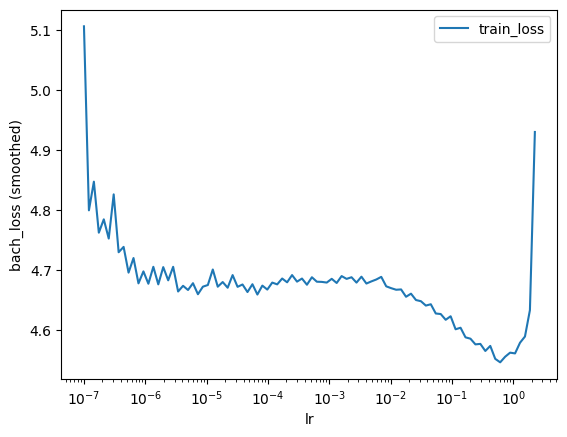

In [11]:
batch_size = 256
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=10)

_ = lrfinder.plot()

In [12]:
learning_rate = lrfinder.get_best_lr()
learning_rate

0.0613590727341321

In [13]:
model.optimizer.set_lr(0.01)

In [14]:
epochs = 200
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=10)]
verbose = True

In [15]:
%%time
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.5853,	val_loss: 3.2505
1:	[0s / 0s],		train_loss: 4.4665,	val_loss: 3.2342
2:	[0s / 0s],		train_loss: 4.7891,	val_loss: 3.2283
3:	[0s / 0s],		train_loss: 4.5582,	val_loss: 3.2247
4:	[0s / 0s],		train_loss: 4.3649,	val_loss: 3.2196
5:	[0s / 0s],		train_loss: 4.4421,	val_loss: 3.2199
6:	[0s / 0s],		train_loss: 4.4713,	val_loss: 3.2135
7:	[0s / 0s],		train_loss: 4.3978,	val_loss: 3.2020
8:	[0s / 0s],		train_loss: 4.3762,	val_loss: 3.2017
9:	[0s / 0s],		train_loss: 4.3638,	val_loss: 3.2043
10:	[0s / 0s],		train_loss: 4.1907,	val_loss: 3.2184
11:	[0s / 0s],		train_loss: 4.4071,	val_loss: 3.2297
12:	[0s / 0s],		train_loss: 4.3415,	val_loss: 3.2447
13:	[0s / 0s],		train_loss: 4.1359,	val_loss: 3.2705
14:	[0s / 0s],		train_loss: 4.4692,	val_loss: 3.2832
15:	[0s / 0s],		train_loss: 4.3484,	val_loss: 3.2818
16:	[0s / 0s],		train_loss: 4.1807,	val_loss: 3.2914
17:	[0s / 0s],		train_loss: 4.2431,	val_loss: 3.3089
18:	[0s / 0s],		train_loss: 4.1591,	val_loss: 3.3222
CPU

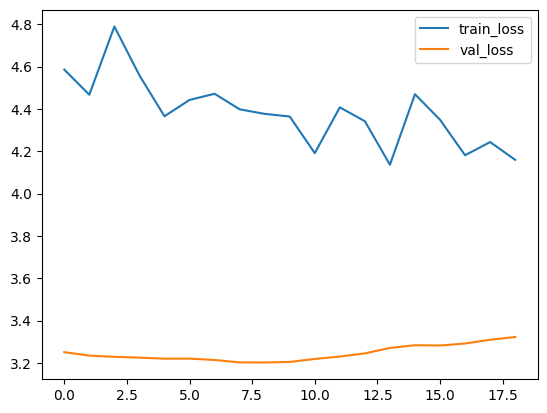

In [16]:
_ = log.plot()

In [17]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()

-3.2016883

In [18]:
log.to_pandas().val_loss.idxmin()

8

Prediction

In [19]:
_ = model.compute_baseline_hazards()

In [20]:
surv = model.predict_surv_df(input=test_X)

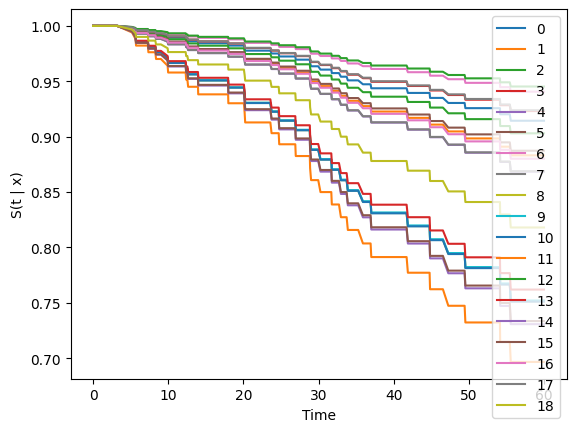

In [24]:
surv.iloc[:, :19].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel("Time")

Evaluation

In [33]:
test_durations = test_durations.cpu().detach().numpy()
test_events = test_events.cpu().detach().numpy()

In [34]:
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


In [35]:
ev.concordance_td()

0.5277777777777778

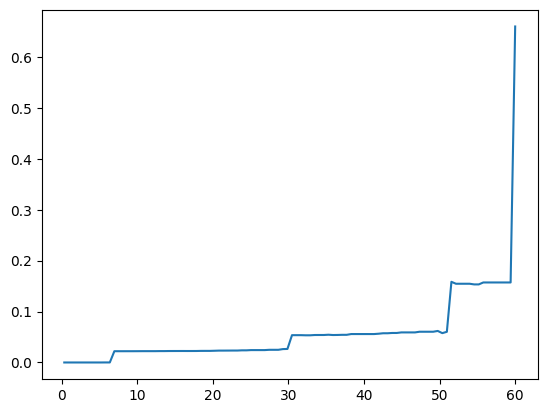

In [36]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [37]:
ev.integrated_brier_score(time_grid=time_grid)

0.05424519405365571

In [38]:
ev.integrated_nbll(time_grid)

0.2062621411483544